# Principal Component Analysis (PCA)

**Course:** MA2221 · Mahindra University  
**Reference:** *Mathematics for Machine Learning*, Deisenroth, Faisal & Ong — Ch 10

---

**Two questions drive this entire lab:**

> *How do we find the directions of maximum variance in data?*  
> *How do we compress high-dimensional data with minimal information loss?*

You will answer both — first by working through the math **by hand in NumPy on toy data**, then by applying **PCA to MNIST** (784-dimensional handwritten digit images), and finally by exploring what PCA keeps and what it throws away.

### Structure
| Section | Topic |
|---|---|
| 1 | Motivation — the Curse of Dimensionality |
| 2 | Problem Setting — Centering, Covariance, Projection |
| 3 | Maximum Variance Perspective — Lagrange Multipliers |
| 4 | Projection Perspective — Reconstruction Error |
| 5 | Eigenvector Computation — from scratch and via SVD |
| 6 | PCA on MNIST — the real deal |

### Legend
- 🧱 **Worked** — run and read
- ✏️ **Your turn** — fill in `___`
- 🔬 **Experiment** — change numbers and observe
- 💬 **Discuss** — no single right answer

---

## 0 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 12,
})
print('Setup complete  ✓')

Setup complete  ✓


---
## Section 1 · Motivation — the Curse of Dimensionality

High-dimensional data is everywhere:
- A 28×28 grayscale image → $\mathbf{x} \in \mathbb{R}^{784}$  
- A 640×480 colour image → $\mathbb{R}^{921{,}600}$  
- Gene expression data: tens of thousands of features

**Key insight:** high-dimensional data often lies near a **low-dimensional subspace**.  
PCA finds that subspace.

**Analogy:** JPEG compresses images by discarding high-frequency components. PCA does the same — it discards the directions of *low* variance.

### 🧱 Visualising a 2-D dataset

We generate 200 points from a 2-D Gaussian with correlated dimensions.  
The data *looks* 2-D, but most of the variance lives along one direction.

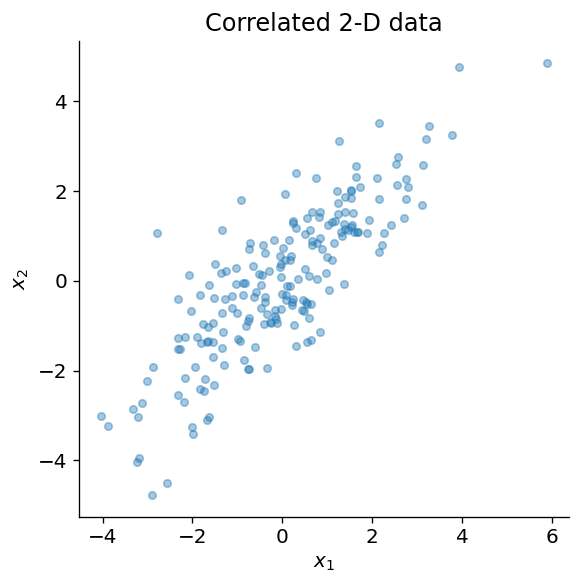

Variance in x1: 2.70
Variance in x2: 2.78


In [2]:
# Generate correlated 2-D data
mean  = [0, 0]
cov   = [[3, 2.5], [2.5, 3]]   # off-diagonal = correlation
X_toy = np.random.multivariate_normal(mean, cov, size=200)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_toy[:, 0], X_toy[:, 1], alpha=0.4, s=20)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Correlated 2-D data')
plt.tight_layout(); plt.show()

print(f'Variance in x1: {X_toy[:,0].var():.2f}')
print(f'Variance in x2: {X_toy[:,1].var():.2f}')

💬 **Discuss:** Looking at the scatter plot, which single direction (line through the origin) do you think captures the most variance? Would $x_1$ or $x_2$ individually do well as a 1-D representation? Why or why not?

---
## Section 2 · Problem Setting

### 2.1 · Dataset & Notation

We have an i.i.d. dataset $\mathcal{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_N\}$, $\mathbf{x}_n \in \mathbb{R}^D$.

**Centering (mean subtraction):**  
We pre-process the data so that:
$$\frac{1}{N}\sum_{n=1}^N \mathbf{x}_n = \mathbf{0}$$

This does **not** change which directions carry the most variance — it only simplifies the algebra.

### 2.2 · The Data Covariance Matrix

With zero-mean data:
$$S = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \mathbf{x}_n^\top = \frac{1}{N} X^\top X \in \mathbb{R}^{D \times D}$$

Key properties of $S$:
- **Symmetric:** $S = S^\top$
- **Positive semi-definite:** $\mathbf{v}^\top S \mathbf{v} \geq 0$ for all $\mathbf{v}$
- Its **diagonal entries** are the variances of each coordinate
- Its **eigenvalues** measure the variance projected along the corresponding eigenvectors

### 2.3 · The Encoder–Decoder Picture

We seek $M$ orthonormal vectors $\mathbf{b}_1, \ldots, \mathbf{b}_M \in \mathbb{R}^D$ arranged as columns of $B \in \mathbb{R}^{D \times M}$, with $B^\top B = I_M$.

| Step | Formula | Meaning |
|---|---|---|
| **Encode** | $\mathbf{z}_n = B^\top \mathbf{x}_n \in \mathbb{R}^M$ | Compress $D$ → $M$ numbers |
| **Decode** | $\tilde{\mathbf{x}}_n = B \mathbf{z}_n = BB^\top \mathbf{x}_n \in \mathbb{R}^D$ | Reconstruct in original space |

### 🧱 Centering and computing the covariance matrix

In [3]:
# Step 1: Centre the data
mu    = X_toy.mean(axis=0)          # shape (D,)
X_c   = X_toy - mu                  # zero-mean data, shape (N, D)

print(f'Mean before centering: {X_toy.mean(axis=0)}')
print(f'Mean after  centering: {X_c.mean(axis=0)}  (≈ 0)')

# Step 2: Compute the covariance matrix  S = (1/N) X_c^T X_c
N, D = X_c.shape
S = (X_c.T @ X_c) / N              # shape (D, D)

print(f'\nCovariance matrix S:\n{S}')
print(f'\nDiagonal (variances per feature): {np.diag(S)}')

Mean before centering: [-0.0298949   0.00886009]
Mean after  centering: [1.63757896e-17 5.38458167e-17]  (≈ 0)

Covariance matrix S:
[[2.69876014 2.27857339]
 [2.27857339 2.78482625]]

Diagonal (variances per feature): [2.69876014 2.78482625]


### ✏️ Your turn 2.1

NumPy also has `np.cov(X.T)` for computing covariance matrices.  
It uses $\frac{1}{N-1}$ (Bessel correction) instead of $\frac{1}{N}$.

1. Compute `S_np = np.cov(X_c.T)` and compare it to `S` computed above.  
2. When $N$ is large, does this difference matter much?

In [ ]:
# Your code here
S_np = ___

print(f'S    (1/N):   \n{S}')
print(f'S_np (1/N-1):\n{S_np}')
print(f'Max absolute difference: {np.abs(S - S_np).max():.4f}')

---
## Section 3 · Maximum Variance Perspective

### 3.1 · Why Maximise Variance?

If we compress data onto a subspace, we should keep the direction along which the data **varies most** — high variance separates data points, low variance means they all cluster together.

**Retaining the most variance ↔ capturing the most information after compression.**

### 3.2 · The 1-D Case: First Principal Component

**Goal:** find the single unit vector $\mathbf{b}_1 \in \mathbb{R}^D$ that maximises the variance of the scalar projections $z_{1n} = \mathbf{b}_1^\top \mathbf{x}_n$.

The variance of those projections:
$$V_1 = \frac{1}{N} \sum_{n=1}^N z_{1n}^2 = \frac{1}{N} \sum_{n=1}^N (\mathbf{b}_1^\top \mathbf{x}_n)^2 = \mathbf{b}_1^\top \underbrace{\left(\frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \mathbf{x}_n^\top\right)}_{=S} \mathbf{b}_1 = \mathbf{b}_1^\top S \mathbf{b}_1$$

**Constrained optimisation problem:**
$$\max_{\mathbf{b}_1} \; \mathbf{b}_1^\top S \mathbf{b}_1 \qquad \text{subject to} \; \|\mathbf{b}_1\|^2 = 1$$

### 3.3 · Solving with Lagrange Multipliers

Form the **Lagrangian**:
$$\mathcal{L}(\mathbf{b}_1, \lambda_1) = \mathbf{b}_1^\top S \mathbf{b}_1 + \lambda_1 (1 - \mathbf{b}_1^\top \mathbf{b}_1)$$

Setting $\nabla_{\mathbf{b}_1} \mathcal{L} = 0$:
$$2 S \mathbf{b}_1 - 2 \lambda_1 \mathbf{b}_1 = \mathbf{0} \implies \boxed{S \mathbf{b}_1 = \lambda_1 \mathbf{b}_1}$$

So $\mathbf{b}_1$ must be an **eigenvector** of $S$. Substituting back:
$$V_1 = \mathbf{b}_1^\top S \mathbf{b}_1 = \mathbf{b}_1^\top (\lambda_1 \mathbf{b}_1) = \lambda_1$$

**The variance equals the eigenvalue** → to maximise $V_1$, choose the **largest eigenvalue** $\lambda_1$.

> **First Principal Component:** The eigenvector of $S$ with the largest eigenvalue $\lambda_1$. Maximum variance achieved: $V_1 = \lambda_1$.

### 3.4 · The M-D Case

Extend greedily: after finding $\mathbf{b}_1, \ldots, \mathbf{b}_{m-1}$, subtract their contribution (deflation) and repeat. The $m$-th principal component is the eigenvector of $S$ with the $m$-th largest eigenvalue $\lambda_m$.

**Total variance captured by $M$ components:**
$$V_M = \lambda_1 + \lambda_2 + \cdots + \lambda_M$$

### 🧱 Eigenvectors of the covariance matrix (toy data)

In [ ]:
# np.linalg.eigh: for symmetric/Hermitian matrices — returns eigenvalues in ASCENDING order
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Sort in DESCENDING order (largest first = first principal component first)
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]   # each COLUMN is one eigenvector

b1 = eigenvectors[:, 0]   # first principal component
b2 = eigenvectors[:, 1]   # second principal component

print(f'Eigenvalues (= variances along PCs): {eigenvalues}')
print(f'Total variance in data:              {eigenvalues.sum():.4f}')
print(f'Fraction retained by PC1:            {eigenvalues[0]/eigenvalues.sum():.1%}')
print(f'\nb1 (first PC): {b1}')
print(f'b2 (second PC): {b2}')
print(f'b1 · b2 = {b1 @ b2:.2e}  (should be ≈ 0 — orthogonal)')

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_c[:, 0], X_c[:, 1], alpha=0.3, s=20, label='Data')

scale = 2.0
ax.annotate('', xy=scale*b1, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.annotate('', xy=scale*b2, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(*(scale*b1 + 0.1), r'$\mathbf{b}_1$  (PC1)', color='red', fontsize=13)
ax.text(*(scale*b2 + 0.1), r'$\mathbf{b}_2$  (PC2)', color='blue', fontsize=13)

ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Principal components of the toy data')
plt.tight_layout(); plt.show()

### ✏️ Your turn 3.1

Verify the key identity $V_1 = \mathbf{b}_1^\top S \mathbf{b}_1 = \lambda_1$ numerically.

In [ ]:
# Compute the quadratic form b1^T S b1
V1_quadform = ___

# Also compute the variance of the projections directly
projections = ___     # scalar projections of each X_c row onto b1
V1_direct   = ___     # variance of those projections (use (1/N) convention)

print(f'lambda_1           = {eigenvalues[0]:.6f}')
print(f'b1^T S b1          = {V1_quadform:.6f}')
print(f'Var of projections = {V1_direct:.6f}')
print(f'All equal?  {np.isclose(eigenvalues[0], V1_quadform) and np.isclose(eigenvalues[0], V1_direct)}')

### 🔬 Experiment 3.2

Change the off-diagonal entry of `cov` in Section 1 from `2.5` to `0` (uncorrelated data).  
Re-run everything. What happens to the principal components?  
What does $b_1$ point along now?

---
## Section 4 · Projection Perspective — Reconstruction Error

The **maximum-variance view** and the **minimum-error view** are two sides of the same coin.

### Reconstruction error
$$J_M = \frac{1}{N} \sum_{n=1}^N \|\mathbf{x}_n - \tilde{\mathbf{x}}_n\|^2$$

where $\tilde{\mathbf{x}}_n = BB^\top \mathbf{x}_n$ is the projection of $\mathbf{x}_n$ onto the $M$-dimensional subspace spanned by the columns of $B$.

### The result (proven via Lagrange multipliers again)
$$J_M = \sum_{j=M+1}^{D} \lambda_j = \underbrace{\sum_{d=1}^D \lambda_d}_{\text{total variance}} - \underbrace{\sum_{m=1}^M \lambda_m}_{\text{retained variance}}$$

Minimising reconstruction error is **identical** to maximising retained variance.  
Both yield the same $B$: the top-$M$ eigenvectors of $S$.

### 🧱 Encoding, decoding and measuring reconstruction error

In [ ]:
def pca_encode_decode(X_centred, B):
    """Encode X into M-D code and decode back to D-D reconstruction."""
    Z      = X_centred @ B          # codes, shape (N, M)
    X_recon = Z @ B.T               # reconstruction, shape (N, D)
    return Z, X_recon

# Project onto 1 principal component
B1 = eigenvectors[:, :1]            # shape (D, 1)
Z1, X_recon1 = pca_encode_decode(X_c, B1)

error_1pc = np.mean(np.sum((X_c - X_recon1)**2, axis=1))

print(f'Reconstruction error (M=1):  {error_1pc:.4f}')
print(f'Should equal lambda_2:       {eigenvalues[1]:.4f}')
print(f'Fraction of variance LOST:   {eigenvalues[1]/eigenvalues.sum():.1%}')
print(f'Fraction of variance KEPT:   {eigenvalues[0]/eigenvalues.sum():.1%}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.scatter(X_c[:, 0], X_c[:, 1], alpha=0.3, s=15, label='Original')
ax.scatter(X_recon1[:, 0], X_recon1[:, 1], alpha=0.3, s=15, color='red', label='Reconstructed (M=1)')
for i in range(0, len(X_c), 10):
    ax.plot([X_c[i,0], X_recon1[i,0]], [X_c[i,1], X_recon1[i,1]],
            'gray', lw=0.5, alpha=0.5)
ax.set_aspect('equal'); ax.legend(fontsize=9)
ax.set_title('Reconstruction from M=1 component')

ax = axes[1]
ax.scatter(Z1[:, 0], np.zeros(len(Z1)), alpha=0.4, s=20)
ax.set_yticks([])
ax.set_xlabel('Code $z_1$  (projection onto $b_1$)')
ax.set_title('1-D compressed representation')

plt.tight_layout(); plt.show()

### ✏️ Your turn 4.1

Using both principal components ($M = 2$), compute the reconstruction and its error.  
What should the reconstruction error be?

In [ ]:
# Use both principal components
B2 = ___                              # shape (D, 2)
Z2, X_recon2 = pca_encode_decode(X_c, B2)

error_2pc = ___

print(f'Reconstruction error (M=2): {error_2pc:.6f}  (should be ≈ 0)')

---
## Section 5 · Eigenvector Computation — From Scratch and via SVD

### 5.1 · Two routes to PCA

| Route | Steps | Best when |
|---|---|---|
| **Eigendecomposition of $S$** | Form $S = \frac{1}{N}X^\top X$; call `np.linalg.eigh(S)` | $D$ is moderate (e.g., $D \leq 1000$) |
| **SVD of $X$** | Call `np.linalg.svd(X, full_matrices=False)`; left singular vectors are the PCs | $N$ or $D$ is large; numerically more stable |

### 5.2 · The SVD connection

If $X = U \Sigma V^\top$ is the thin SVD of the centred data matrix, then:
- **Principal components** (columns of $B$) = **right singular vectors** = columns of $V$
- **Eigenvalues** of $S$: $\lambda_m = \sigma_m^2 / N$, where $\sigma_m$ are the singular values
- **Codes** $Z = X V$ (equivalently $U \Sigma$)

### 🧱 SVD route vs eigendecomposition route

In [ ]:
# SVD of the centred data matrix
U_svd, sigma, Vt = np.linalg.svd(X_c, full_matrices=False)
V = Vt.T                      # columns = principal components

eigenvalues_svd = sigma**2 / N

print('Eigenvalues via eigh:   ', eigenvalues)
print('Eigenvalues via SVD:    ', eigenvalues_svd)

# Note: sign of eigenvectors can flip — compare absolute values
print('\n|b1 via eigh| ≈ |b1 via SVD|?', np.allclose(np.abs(eigenvectors[:,0]),
                                                       np.abs(V[:,0])))

### ✏️ Your turn 5.1

Using the SVD result, compute the 1-D codes and reconstruction for the toy data.  
Verify that the reconstruction error matches what you found in Section 4.

In [ ]:
# First principal component from SVD
b1_svd = ___                          # first column of V

# Codes and reconstruction
Z1_svd     = ___                      # shape (N, 1)
X_recon_svd = ___                     # shape (N, D)

error_svd = np.mean(np.sum((X_c - X_recon_svd)**2, axis=1))
print(f'Reconstruction error via SVD route: {error_svd:.4f}')
print(f'Matches Section 4?  {np.isclose(error_svd, error_1pc)}')

---
## Section 6 · PCA on MNIST

MNIST consists of 70,000 handwritten digit images (0–9).  
Each image: 28×28 pixels → vector $\mathbf{x} \in \mathbb{R}^{784}$.

**PCA goal on MNIST:**
- Find a subspace of dimension $M \ll 784$
- Represent each digit with only $M$ numbers
- Reconstruct with minimal visual loss

For $M = 2$ we compress each image from **784 numbers down to 2** — a 392× reduction.

### 🧱 Load MNIST and centre the data

In [ ]:
# Load MNIST (this may take ~30 s the first time)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist = mnist.data.astype(float)   # shape (70000, 784)
y_mnist = mnist.target

# Use a subset for speed
X_mnist = X_mnist[:5000]
y_mnist = y_mnist[:5000]

# Centre
mu_mnist  = X_mnist.mean(axis=0)
Xc_mnist  = X_mnist - mu_mnist

print(f'Data matrix shape : {Xc_mnist.shape}  (N=5000, D=784)')
print(f'Mean of centred data: {Xc_mnist.mean():.2e}  (should be ≈ 0)')

### 🧱 Covariance matrix and eigendecomposition

In [ ]:
N_m, D_m = Xc_mnist.shape

# Covariance matrix  S = (1/N) X_c^T X_c
S_mnist = (Xc_mnist.T @ Xc_mnist) / N_m   # shape (784, 784)
print(f'Covariance matrix shape: {S_mnist.shape}')

# Eigendecomposition (may take ~10 s)
eigvals_m, eigvecs_m = np.linalg.eigh(S_mnist)

# Sort descending
idx_m        = np.argsort(eigvals_m)[::-1]
eigvals_m    = eigvals_m[idx_m]
eigvecs_m    = eigvecs_m[:, idx_m]   # shape (784, 784)

print(f'Top-5 eigenvalues: {eigvals_m[:5].astype(int)}')
print(f'Total variance: {eigvals_m.sum():.1f}')

### 🧱 Scree plot — how much variance does each component capture?

In [ ]:
total_var      = eigvals_m.sum()
explained_var  = eigvals_m / total_var          # fraction per component
cumulative_var = np.cumsum(explained_var)        # cumulative fraction

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.bar(range(1, 51), explained_var[:50] * 100)
ax.set_xlabel('Principal component index')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Individual variance (Scree plot)')

ax = axes[1]
ax.plot(range(1, len(cumulative_var)+1), cumulative_var * 100)
for threshold in [0.5, 0.8, 0.95]:
    m_thresh = np.searchsorted(cumulative_var, threshold) + 1
    ax.axhline(threshold * 100, color='gray', linestyle='--', lw=0.8)
    ax.text(210, threshold * 100 + 0.5, f'{threshold:.0%} → M={m_thresh}', fontsize=8)
ax.set_xlabel('Number of components M')
ax.set_ylabel('Cumulative variance (%)')
ax.set_title('Cumulative variance explained')

plt.tight_layout(); plt.show()

for threshold in [0.5, 0.8, 0.95]:
    m_thresh = np.searchsorted(cumulative_var, threshold) + 1
    print(f'M needed for {threshold:.0%} variance: {m_thresh}')

### ✏️ Your turn 6.1 — Reconstruct MNIST digits

Complete the function below to encode and decode MNIST images, then visualise the reconstruction quality for different values of $M$.

In [ ]:
def reconstruct_mnist(Xc, eigvecs, mu, M):
    """Return reconstructed images (before adding mean back)."""
    B    = ___            # top-M eigenvectors, shape (784, M)
    Z    = ___            # codes, shape (N, M)
    Xrec = ___            # reconstruction in centred space, shape (N, 784)
    return Xrec + mu      # add mean back

# Visualise reconstructions for several M values
M_values = [1, 5, 20, 50, 100, 200]
n_show   = 5
digits   = Xc_mnist[:n_show]   # first 5 images

fig, axes = plt.subplots(n_show, len(M_values) + 1, figsize=(13, 5))

for row in range(n_show):
    axes[row, 0].imshow((digits[row] + mu_mnist).reshape(28, 28), cmap='gray', vmin=0, vmax=255)
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=8)

    for col, M in enumerate(M_values, start=1):
        recon = reconstruct_mnist(Xc_mnist, eigvecs_m, mu_mnist, M)
        axes[row, col].imshow(recon[row].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'M={M}', fontsize=8)

plt.suptitle('MNIST reconstructions for different M', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

### ✏️ Your turn 6.2 — Visualise the principal components

Each principal component $\mathbf{b}_m \in \mathbb{R}^{784}$ can be reshaped into a 28×28 image — called an **eigenface** (or here, **eigendigit**).  
Visualise the first 16 principal components of MNIST.

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(7, 7))

for i, ax in enumerate(axes.flat):
    pc = ___             # i-th column of eigvecs_m, reshaped to (28, 28)
    ax.imshow(pc, cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('First 16 principal components (eigendigits)', fontsize=11)
plt.tight_layout(); plt.show()

### ✏️ Your turn 6.3 — 2-D scatter of MNIST digits

Project all 5000 images onto the first **two** principal components and plot a scatter coloured by digit label.  
Do different digit classes cluster in the 2-D space?

In [ ]:
# Project onto first 2 PCs
B2_mnist = ___            # shape (784, 2)
Z2_mnist = ___            # codes, shape (5000, 2)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(Z2_mnist[:, 0], Z2_mnist[:, 1],
                     c=y_mnist.astype(int), cmap='tab10',
                     s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Digit label')
ax.set_xlabel('Code $z_1$  (PC1)')
ax.set_ylabel('Code $z_2$  (PC2)')
ax.set_title('MNIST projected onto first 2 principal components')
plt.tight_layout(); plt.show()

### 🧱 Reconstruction error vs M

In [ ]:
M_range = list(range(1, 11)) + list(range(20, 210, 10))
errors  = []

for M in M_range:
    B   = eigvecs_m[:, :M]
    Z   = Xc_mnist @ B
    Xrec = Z @ B.T
    err  = np.mean(np.sum((Xc_mnist - Xrec)**2, axis=1))
    errors.append(err)

# Theoretical values from eigenvalues
errors_theory = [eigvals_m[M:].sum() for M in M_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(M_range, errors, label='Empirical error')
ax.plot(M_range, errors_theory, '--', label=r'$\sum_{j>M} \lambda_j$ (theory)', alpha=0.7)
ax.set_xlabel('Number of components M')
ax.set_ylabel('Average squared reconstruction error')
ax.set_title('Reconstruction error vs M')
ax.legend()
plt.tight_layout(); plt.show()

💬 **Discuss:**
1. How quickly does the error drop as you add more components?
2. What does it mean that the empirical error closely matches the theoretical prediction $\sum_{j>M} \lambda_j$?
3. For a practical application (e.g., image compression), how would you choose $M$?

---
## Summary

| Concept | Formula / Key fact |
|---|---|
| Covariance matrix | $S = \frac{1}{N} X^\top X$ |
| Variance along direction $\mathbf{b}$ | $\mathbf{b}^\top S \mathbf{b}$ (quadratic form) |
| Optimal direction (1-D) | Eigenvector of $S$ with **largest** eigenvalue |
| $m$-th principal component | Eigenvector of $S$ with $m$-th largest eigenvalue $\lambda_m$ |
| Total variance retained (M components) | $V_M = \sum_{m=1}^M \lambda_m$ |
| Reconstruction error (M components) | $J_M = \sum_{j=M+1}^D \lambda_j$ |
| Encoder | $\mathbf{z}_n = B^\top \mathbf{x}_n$ |
| Decoder | $\tilde{\mathbf{x}}_n = B \mathbf{z}_n$ |
| Choose M | Use scree plot / variance threshold (e.g. 95%) |

**Both the maximum-variance and minimum-reconstruction-error perspectives lead to the same answer: the top-$M$ eigenvectors of the data covariance matrix.**